# Machine Learning Modelagem Multi-Classe

**Sobre o Dataset**
- Dataset Articial (by IA) de risco de desenvolver diabetes baseado em habitos e hemogramas.
- 3 classes: Risco Baixo, Risco Médio e Risco Alto.

**Objetivo***

Treinar um modelo de classificação seguindo os requisitos abaixo, analisar e explicar os resultados e realizar uma auto-avaliação do seu modelo.

**Requisitos**
- Fazer Treino, Validação e Teste
- Fine Tunning
- Usar modelos de arvores (Decision Tree, Random Forest, XGbost)
- Usar modelos base (Regressão Logística e KNN)
- Validação Cruzada
- Oversampling e Undersampling

---

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None) #exibe todas as colunas do dataframe

In [ ]:
print(pd.__version__)

2.2.3


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mansiaggarwal88/diabetes-risk-prediction")

print("Path to dataset files:", path)

df = pd.read_csv(f'{path}/diabetes_risk.csv')

100%|██████████| 323k/323k [00:00<00:00, 56.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mansiaggarwal88/diabetes-risk-prediction/versions/1


## 1. Análise Exploratória do Dataset

- 19 colunas
- 15k linhas

Linhas com valores nulos:
- alcohol_consumption (qualitativa)
- smoking_status (qualitativa)
- income_bracket (qualitativa)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

Distribuição da Variavel Resposta
- Risco Baixo: 9000 (60%)
- Risco Moderado: 3750 (25%)
- Risco Alto: 2250 (15%)

<Axes: ylabel='proportion'>

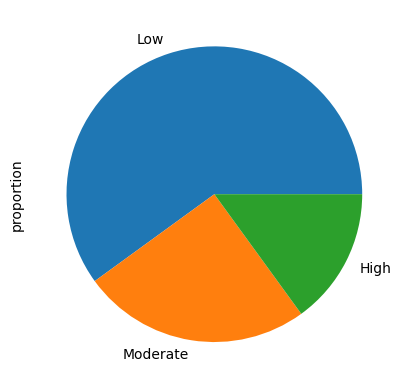

In [ ]:
df['diabetes_risk'].value_counts(normalize = True).plot(kind='pie')

Colunas
- idade
- genero
- cidade (pode ser relevante pela cultura de alimentação)
- bmi (indice de massa corporal)
- historia familiar de diabetes
- atividade física
- tipo de dieta (vegana, vegetaria, só peixes e não vegetariana)
- status de fumante
- nivel de consumo de alcool
- horas por noite
- nivel de stress
- insulina
- hba1c
- pressao sanguinia
- outro tipo de pressao sanguinia
- cm cintura
- faixa de renda

In [ ]:
df['diet_type'].value_counts()

,count
diet_type,
Non-Vegetarian,8195
Vegetarian,6074
Pescatarian,445
Vegan,286


In [ ]:
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [ ]:
df.tail()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
14995,14996,47,Male,Mumbai,37.7,No,Sedentary,Non-Vegetarian,Never,Never,6.8,7,213,8.1,150,100,141.7,High,High
14996,14997,48,Female,Mumbai,20.6,No,Moderate,Non-Vegetarian,Never,NaN,6.0,8,162,6.5,132,80,91.0,NaN,Low
14997,14998,34,Female,Nagpur,17.9,No,Active,Vegetarian,Never,Never,7.0,6,137,6.5,136,90,88.8,Low,Low
14998,14999,56,Male,Ahmedabad,20.7,Yes,Active,Vegetarian,Never,Never,6.0,5,163,6.9,140,87,94.8,Low,Low
14999,15000,54,Male,Surat,34.5,No,Moderate,Vegetarian,Never,Never,7.4,2,186,7.2,150,88,130.4,Middle,Moderate


Fiz uma analise mais supercial nos dados, agora quero entender as partes mais estatísticas como:
- distribuições (quartis, desvio padrão, media e mediana)
- correlações (person para correlações lineares e spearmen para correlação monotonicas)
- nova correlação (kendall)

| Correlação   | O que mede                  | Tipo de relação    | Sensibilidade a outliers |
| ------------ | --------------------------- | ------------------ | ------------------------ |
| **Pearson**  | Associação linear           | Linear             | Alta                     |
| **Spearman** | Associação monotônica       | Monotônica         | Menor                    |
| **Kendall**  | Concordância entre rankings | Monotônica/ordinal | Baixa                    |


---
Léo, nós paramos em realizar as correlações, as features são faceis de ler, mas precisamos entender suas correlações.

Tambem vale te lembrar que temos 3 classes para o modelo prever.

---